<a href="https://colab.research.google.com/github/wilson-luu/econ3916-lab04-anomaly-detection/blob/main/lab_ch04_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Automated Anomaly Detection
## ECON 3916: Applied Machine Learning for Economists
### Guided Construction Lab | 8 min Part 0 + 30 min Core + 15 min Extension + take-home Challenge

---

**Learning Objectives:**
- Compute and compare robust vs. non-robust summary statistics on skewed economic data
- Implement Tukey Fences manually and understand why each step matters
- Visualize outlier boundaries on histograms and boxplots
- Apply `IsolationForest` from scikit-learn and compare its flags to Tukey Fences

**Dataset:** California Housing (sklearn) — the same dataset you will revisit in Ch 12, 15, 16, and 19

**How this lab works:** Parts 0-3 are GUIDED: run each cell as it is, then answer the questions. The Extension is optional. The Challenge is an optional take-home where you write your first function.

**Prerequisites:** Part 0 of this lab (below), plus Chapter 4 reading (robust statistics, Tukey Fences, Isolation Forest)

**AI in the manual parts:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion while you work on those parts. AI-assisted coding is allowed only where this lab says so.

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import trim_mean, median_abs_deviation
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42          # one seed for every random step in this lab

plt.style.use("seaborn-v0_8-whitegrid")

df = fetch_california_housing(as_frame=True).frame

print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
print(list(df.columns))
df.head(3)

20,640 rows x 9 columns
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


**Expected output:** 20,640 rows x 9 columns. Features include `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`, `MedHouseVal`. The target `MedHouseVal` is the median house value for each census block group, in units of \$100,000.

<!-- 3916-onramp -->
## Part 0: The Floor (GUIDED — 8 min)

Part 0 of Labs 1 through 5 teaches the slice of Python that lab needs, next to
the data that needs it. Run every cell before going on.

**This lab's slice:** dictionaries, `.quantile()`, and labelling rows with `.loc`.

The Extension's `compute_all_measures()` returns a **dictionary**, and the
Challenge's `flag_outliers()` labels rows with `.loc`. Neither has come up
before, so they come first.

In [2]:
# GUIDED — run as-is
# Step 0: dictionaries, quantiles, and labelling rows

# A dictionary: you look a value up by its key, not by its position
fences = {"lower": 1.5, "upper": 3.2, "method": "iqr"}
print("The dict:  ", fences)
print("One value: ", fences["upper"])
print("Its keys:  ", list(fences.keys()))

# Assigning to a new key adds it
fences["n_flagged"] = 0
print("After adding one:", fences)

# A for loop over a dictionary walks its keys
print("\n--- each entry ---")
for key in fences:
    print(" ", key, fences[key])

# .quantile() gives the quartiles the fences are built from
demo = pd.Series([1, 2, 2, 3, 3, 3, 4, 4, 9, 40])
q1 = demo.quantile(0.25)
q3 = demo.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"\nq1={q1}, q3={q3}, iqr={iqr}  ->  upper fence {upper}")
print(f"Values beyond it: {list(demo[demo > upper])}")

# .loc[condition, column] = value changes only the rows where the condition is True
frame = pd.DataFrame({"district": ["A", "B", "C"], "rooms": [5.1, 3.2, 41.0]})
frame["flag"] = "ok"
frame.loc[frame["rooms"] > 10, "flag"] = "outlier"
print()
print(frame.to_string(index=False))

The dict:   {'lower': 1.5, 'upper': 3.2, 'method': 'iqr'}
One value:  3.2
Its keys:   ['lower', 'upper', 'method']
After adding one: {'lower': 1.5, 'upper': 3.2, 'method': 'iqr', 'n_flagged': 0}

--- each entry ---
  lower 1.5
  upper 3.2
  method iqr
  n_flagged 0

q1=2.25, q3=4.0, iqr=1.75  ->  upper fence 6.625
Values beyond it: [9, 40]

district  rooms    flag
       A    5.1      ok
       B    3.2      ok
       C   41.0 outlier


---

## Part 1: Robust vs. Non-Robust Summary Statistics (GUIDED — 8 min)

Chapter 4 showed that the arithmetic mean gets dragged around by extreme values. The median, trimmed mean, IQR, and MAD resist that pull. Let's see this concretely on housing prices.

In [3]:
# GUIDED — run as-is
# Step 1: the distribution of house values

prices = df["MedHouseVal"]        # units of $100,000

print(prices.describe().round(4))
print(f"\nSkewness: {prices.skew():.4f}")

count    20640.0000
mean         2.0686
std          1.1540
min          0.1500
25%          1.1960
50%          1.7970
75%          2.6472
max          5.0000
Name: MedHouseVal, dtype: float64

Skewness: 0.9778


**Expected output:** The max value is 5.00001 (\$500,001 — a cap imposed by the Census Bureau). Skewness should be positive (~0.98), confirming the right-skewed distribution the chapter described. A longer right tail pulls the mean above the median, which Step 2 measures.

In [4]:
# GUIDED — run as-is
# Step 2: the six summary measures from Chapter 4

# Center
mean = prices.mean()
median = prices.median()
trimmed_mean = trim_mean(prices, 0.10)     # drop the top and bottom 10%, then average

# Spread
std = prices.std()
q1 = prices.quantile(0.25)
q3 = prices.quantile(0.75)
iqr = q3 - q1
mad = median_abs_deviation(prices)         # the median distance from the median

gap = mean - median
print(f"Mean:   {mean:.4f}")
print(f"Median: {median:.4f}")
print(f"Gap:    {gap:.4f}, or ${gap * 100000:,.0f}")

Mean:   2.0686
Median: 1.7970
Gap:    0.2716, or $27,156


**Expected output:** Mean (~2.07) should exceed the median (~1.80). The trimmed mean, in the table below, sits between them. The gap tells you that extreme housing values are pulling the mean upward — exactly the phenomenon from the chapter's net-worth example.

In [5]:
# GUIDED — run as-is
# Step 3: all six measures in one table (for your portfolio)

summary_table = pd.DataFrame({
    "Measure": ["Mean", "Median", "Trimmed Mean (10%)", "Std Deviation", "IQR", "MAD"],
    "Value": [mean, median, trimmed_mean, std, iqr, mad],
    "Robust": ["No", "Yes", "Yes", "No", "Yes", "Yes"],
    "What it measures": [
        "Center of gravity (pulled by extremes)",
        "50th percentile (ignores magnitude)",
        "Mean after removing extreme tails",
        "Average distance from mean (pulled by extremes)",
        "Width of the middle 50% of data",
        "Median distance from the median",
    ],
})
summary_table["Value"] = summary_table["Value"].round(4)

print(summary_table.to_string(index=False))

           Measure  Value Robust                                What it measures
              Mean 2.0686     No          Center of gravity (pulled by extremes)
            Median 1.7970    Yes             50th percentile (ignores magnitude)
Trimmed Mean (10%) 1.9277    Yes               Mean after removing extreme tails
     Std Deviation 1.1540     No Average distance from mean (pulled by extremes)
               IQR 1.4512    Yes                 Width of the middle 50% of data
               MAD 0.6840    Yes                 Median distance from the median


### Interpretation Questions

**Q1:** The trimmed mean (10%) sits between the mean and the median. Why? What is it doing mechanically that produces this middle-ground result?

**Q2:** A real estate company reports that the "average home value" in California is \$207,000 (based on this dataset). A housing activist says the "typical home value" is \$180,000. Who is right? Why does the word choice matter for policy?

**Q3:** The MAD is much smaller than the standard deviation. What does this tell you about how much the extreme values inflate the spread measurement?

*Your answers here:*

1. The trimmed mean sits between the mean and the median because it drops the top and bottom 10% of the data before averaging. Because housing prices are highly right-skewed, dropping the top 10% removes the extreme high values that pull the mean upward. This measure acts as a middle-ground by keeping the bulk of the data while ignoring any extreme outliers.
2. Both are mathematically correct, but the housing activist is painting a more accurate picture of the typical experience. The real estate company is allowing a small number of ultra-wealthy properties to inflate the average. Word choice is important for policy, like affordable housing subsidies or tax brackets, because using the mean artificially exaggerates the wealth of the typical resident.
3. The standard deviation squares the distances from the mean, meaning extreme outliers have an exponentially outsized impact on it. The MAD being so much smaller proves that the spread measured by the standard deviation is massively inflated by the extreme skewness, rather than reflecting the actual dispersion of the middle of the market.

---

## Part 2: Tukey Fences — Manual Outlier Detection (GUIDED — 10 min)

John Tukey's fence rule is the workhorse of exploratory outlier detection:
- **Lower fence** = Q1 - 1.5 * IQR
- **Upper fence** = Q3 + 1.5 * IQR

Any observation outside these fences is flagged as a potential outlier. The 1.5 multiplier is not magic — for a normal distribution, it captures ~99.3% of data, flagging only the most extreme ~0.7%.

In [6]:
# GUIDED — run as-is
# Step 4: Tukey fences, by hand

q1 = prices.quantile(0.25)
q3 = prices.quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

tukey_outliers = (prices < lower_fence) | (prices > upper_fence)

print(f"Q1 = {q1:.4f}   Q3 = {q3:.4f}   IQR = {iqr:.4f}")
print(f"Lower fence = Q1 - 1.5*IQR = {lower_fence:.4f}")
print(f"Upper fence = Q3 + 1.5*IQR = {upper_fence:.4f}")
print()
# .sum() of True/False counts the Trues; .mean() is the share that is True
print(f"Flagged: {tukey_outliers.sum():,} of {len(prices):,} ({tukey_outliers.mean() * 100:.1f}%)")
print(f"  below the lower fence: {(prices < lower_fence).sum()}")
print(f"  above the upper fence: {(prices > upper_fence).sum()}")
print(f"  at the $500,001 cap:   {(prices == prices.max()).sum()}")

Q1 = 1.1960   Q3 = 2.6472   IQR = 1.4512
Lower fence = Q1 - 1.5*IQR = -0.9809
Upper fence = Q3 + 1.5*IQR = 4.8241

Flagged: 1,071 of 20,640 (5.2%)
  below the lower fence: 0
  above the upper fence: 1071
  at the $500,001 cap:   965


**Expected output:** The lower fence is negative (-0.98), below any possible price, so nothing is flagged low. All 1,071 flags are above the upper fence (about 4.82), and 965 of them sit at the Census cap of \$500,001.

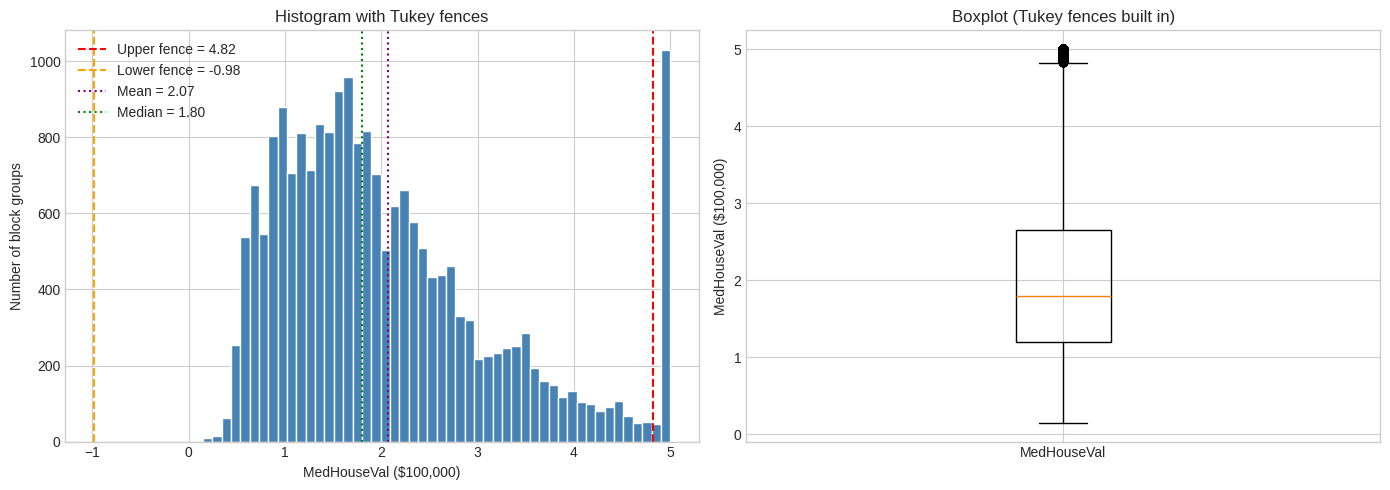

In [7]:
# GUIDED — run as-is
# Step 5: the fences on a histogram, and on a boxplot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(prices, bins=50, color="steelblue", edgecolor="white")
ax.axvline(upper_fence, color="red", linestyle="--", label=f"Upper fence = {upper_fence:.2f}")
ax.axvline(lower_fence, color="orange", linestyle="--", label=f"Lower fence = {lower_fence:.2f}")
ax.axvline(mean, color="purple", linestyle=":", label=f"Mean = {mean:.2f}")
ax.axvline(median, color="green", linestyle=":", label=f"Median = {median:.2f}")
ax.set_xlabel("MedHouseVal ($100,000)")
ax.set_ylabel("Number of block groups")
ax.set_title("Histogram with Tukey fences")
ax.legend()

# A boxplot draws Tukey fences for you: each whisker stops at the last point
# inside a fence, and every dot beyond it is a Tukey outlier.
ax = axes[1]
ax.boxplot(prices)
ax.set_xticklabels(["MedHouseVal"])
ax.set_ylabel("MedHouseVal ($100,000)")
ax.set_title("Boxplot (Tukey fences built in)")

plt.tight_layout()
plt.show()

### Interpretation Questions

In the boxplot, the dots above the top whisker are the Tukey outliers. The pile at 5.0 is the Census cap at \$500,001.

**Q1:** The lower fence is negative, so no observations fall below it. Does this mean there are no low-value outliers in the data, or does it mean Tukey Fences are not designed to catch them here? What would a different method (e.g., domain knowledge) flag as suspiciously low?

**Q2:** Many of the upper outliers are at exactly 5.00001. Are these genuine extreme observations or an artifact of data collection? How should an analyst handle them?

*Your answers here:*

1. It means Tukey Fences are not designed to catch low-value outliers in highly right-skewed data that is bounded near zero. The symmetry of the IQR pushes the mathematical lower fence below zero, which is impossible for housing prices.
2. These are an artifact of data collection. Specifically, the US Census Bureau capping all house values above \$500,000 into a single bin. An analyst should handle them by treating them as right-censored data. These values should not blindly deleted as outliers, but also cannot be treated as continuous, normal data points in a linear regression.

---

## Part 3: Isolation Forest — Algorithmic Anomaly Detection (GUIDED — 12 min)

Tukey Fences work on one variable at a time. But real anomalies are often *multivariate* — a house might have a normal price but an absurd number of rooms for its size. **Isolation Forest** detects these by asking: how easy is it to isolate this observation from the rest? Outliers are isolated quickly; normal points require many splits.

This is a preview of the tree-based methods you will study in depth in Chapter 19.

<!-- idiom-note -->
> ### New idiom — the estimator: build it, fit it, ask it
>
> Every model in this course, from here to the end, follows one three-step
> pattern. It is worth learning once, deliberately:
>
> ```python
> model = IsolationForest(contamination=0.05, random_state=42)  # 1. BUILD — set the options
> model.fit(X)                                                  # 2. FIT   — learn from data
> flags = model.predict(X)                                      # 3. ASK   — get an answer
> ```
>
> This is different from everything so far. `np.mean(x)` is a function you
> hand data to, and it gives an answer and forgets. An **estimator** is an
> *object*: you construct it with settings, `.fit()` teaches it and it
> **remembers** what it learned, and `.predict()` uses that memory. The
> learned state lives on the object — that is why the same model can score new
> data later.
>
> You will see `.fit_predict(X)` too. It is just steps 2 and 3 in one call.


In [8]:
# GUIDED — run as-is
# Step 6: fit an Isolation Forest on the 8 features

# Every column except the price: the forest looks for rows that are unusual
# as a combination, not in one column
features = df.drop(columns=["MedHouseVal"])

iso_forest = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)  # 1. build
iso_forest.fit(features)                                                      # 2. fit
labels = iso_forest.predict(features)                                         # 3. ask: 1 = normal, -1 = outlier
forest_flags = labels == -1

# Below 0 means flagged as an outlier; the more negative, the more unusual
forest_scores = iso_forest.decision_function(features)

print(f"Flagged: {forest_flags.sum():,} of {len(df):,} ({forest_flags.mean() * 100:.1f}%)")
print(f"Anomaly scores run from {forest_scores.min():.4f} to {forest_scores.max():.4f}")

Flagged: 1,032 of 20,640 (5.0%)
Anomaly scores run from -0.2116 to 0.1565


**Expected output:** With `contamination=0.05`, the Isolation Forest should flag approximately 1,032 observations (5% of 20,640).

In [9]:
# GUIDED — run as-is
# Step 7: where do Tukey and the forest agree?

# .values drops the row labels, so it lines up with forest_flags, a plain array
tukey_flags = tukey_outliers.values

# & means AND, ~ means NOT
both = (tukey_flags & forest_flags).sum()
tukey_only = (tukey_flags & ~forest_flags).sum()
forest_only = (~tukey_flags & forest_flags).sum()
neither = (~tukey_flags & ~forest_flags).sum()

agree = both + neither
print(f"Both flag:         {both:,}")
print(f"Only Tukey flags:  {tukey_only:,}")
print(f"Only forest flags: {forest_only:,}")
print(f"Neither flags:     {neither:,}")
print(f"\nThe two methods agree on {agree:,} rows ({agree / len(df) * 100:.1f}%)")

Both flag:         165
Only Tukey flags:  906
Only forest flags: 867
Neither flags:     18,702

The two methods agree on 18,867 rows (91.4%)


**Expected output:** Agreement looks high (about 91%) only because most rows are flagged by neither method. Among the rows that are flagged, the methods mostly disagree: only 165 are flagged by both. Tukey looks only at `MedHouseVal`; the forest uses all 8 features. The "Only Tukey" rows have extreme prices but ordinary features. The "Only forest" rows are the interesting ones: ordinary prices, but unusual combinations of rooms, occupancy or location.

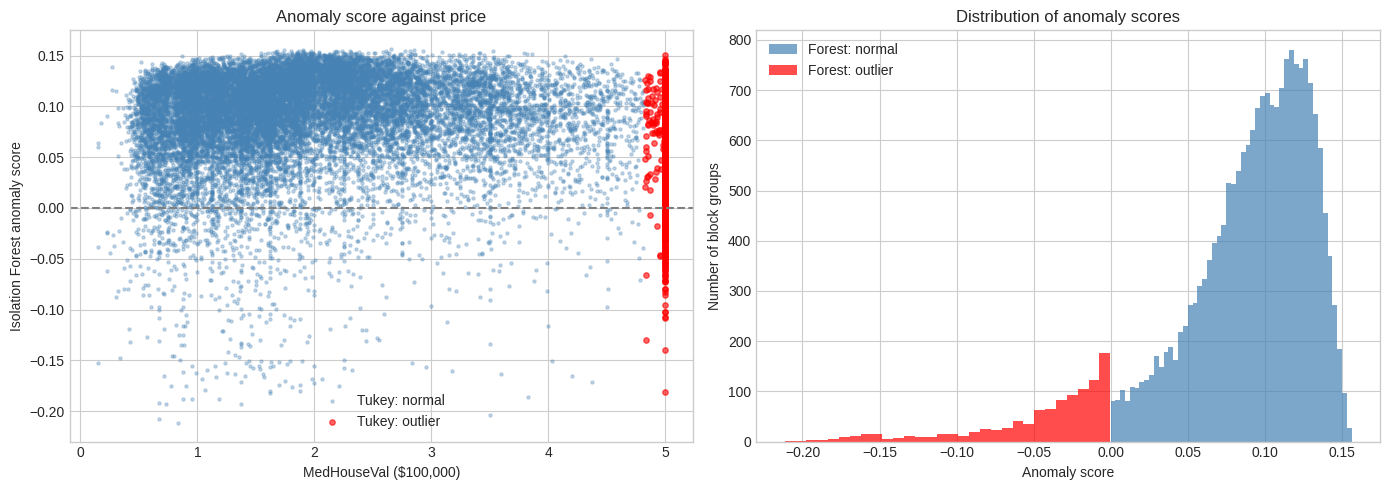

In [10]:
# GUIDED — run as-is
# Step 8: the anomaly scores, two ways

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(prices[~tukey_flags], forest_scores[~tukey_flags], s=5, alpha=0.3, color="steelblue", label="Tukey: normal")
ax.scatter(prices[tukey_flags], forest_scores[tukey_flags], s=15, alpha=0.6, color="red", label="Tukey: outlier")
ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("MedHouseVal ($100,000)")
ax.set_ylabel("Isolation Forest anomaly score")
ax.set_title("Anomaly score against price")
ax.legend()

ax = axes[1]
ax.hist(forest_scores[~forest_flags], bins=50, alpha=0.7, color="steelblue", label="Forest: normal")
ax.hist(forest_scores[forest_flags], bins=30, alpha=0.7, color="red", label="Forest: outlier")
ax.set_xlabel("Anomaly score")
ax.set_ylabel("Number of block groups")
ax.set_title("Distribution of anomaly scores")
ax.legend()

plt.tight_layout()
plt.show()

**Reading the two panels.** Left: every Tukey outlier (red) sits at a high
price, yet most have scores above 0, which means the forest treats those rows
as normal. Step 7 counted them: 906 of the 1,071. Right: the forest flags the 5%
of rows with the lowest scores. The two methods measure different things.

In [11]:
# GUIDED — run as-is
# Step 9: what makes the forest-only rows unusual?

forest_only_rows = ~tukey_flags & forest_flags

# A ratio of two average map coordinates is always close to 1, so leave them out
numbers = df.drop(columns=["Latitude", "Longitude"])

compare_means = pd.DataFrame({
    "All data": numbers.mean(),
    "Forest-only rows": numbers[forest_only_rows].mean(),
})
compare_means["Ratio"] = compare_means["Forest-only rows"] / compare_means["All data"]

print(compare_means.round(3).to_string())

             All data  Forest-only rows  Ratio
MedInc          3.871             3.713  0.959
HouseAge       28.639            20.606  0.719
AveRooms        5.429             9.265  1.707
AveBedrms       1.097             1.920  1.751
Population   1425.477          2474.707  1.736
AveOccup        3.071             6.544  2.131
MedHouseVal     2.069             1.708  0.826


**Expected output:** Look for ratios far from 1.0: those features drive the forest's flags. The forest-only rows should show unusually high `AveOccup` or `Population` values — census blocks with extreme crowding or population density. These are multivariate anomalies that a univariate method like Tukey Fences would miss entirely.

### Interpretation Questions

**Q1:** Tukey Fences found outliers based on price alone. Isolation Forest found outliers based on all features. Which approach is more appropriate for a real estate analyst? When would you prefer one over the other?

**Q2:** The `contamination` parameter in Isolation Forest was set to 0.05 (5%). How would changing this to 0.01 or 0.10 affect the results? Is there an objectively correct contamination rate?

**Q3:** (Callback to Ch 3) If you only looked at summary statistics and never plotted the data, which of these outlier patterns would you have missed?

*Your answers here:*

1. Isolation Forest is much more appropriate for a real estate analyst. Housing prices are strictly contextual and Tukey Fences only look at price in a vacuum. Tukey Fences are preferred for more basic checks, but Isolation Forest for more robust economic anomaly detection.
2. Changing it to 0.01 would force the algorithm to flag only the most extreme 1% of observations, while 0.10 would cast a wider net and flag 10%. There is no objectively correct contamination rate. Instead, it is a subjective heuristic threshold chosen by the analyst based on their domain knowledge and tolerance for false positives.
3. Without plotting the data, it would be easy to miss the massive artificial cap at exactly $500,001 in the price distribution. It would also be easy to miss the multivariate anomalies, like severe overcrowding, that the Isolation Forest caught.

---

## Extension: Contamination Experiment (Optional — 15 min)

Chapter 4 demonstrated that the mean is sensitive to contamination while robust measures resist it. Let's prove this empirically: we will randomly corrupt 5% of the data and see which measures break.

In [ ]:
# EXTENSION — run as-is
# Step 10: corrupt 5% of the prices on purpose

np.random.seed(RANDOM_STATE)

prices_clean = prices.copy()
prices_contaminated = prices.copy()

n_contaminate = int(len(prices) * 0.05)
contaminate_idx = np.random.choice(prices.index, size=n_contaminate, replace=False)

# Overwrite them with values from $1M to $5M (10 to 50 in the data's units),
# the way a data-entry error might
prices_contaminated.loc[contaminate_idx] = np.random.uniform(10, 50, n_contaminate)

print(f"Replaced {n_contaminate:,} values ({n_contaminate / len(prices) * 100:.1f}%)")
print(f"Largest price before: {prices_clean.max():.4f}")
print(f"Largest price after:  {prices_contaminated.max():.4f}")

In [ ]:
# EXTENSION — run as-is
# Step 11: the six measures, before and after

def compute_all_measures(series):
    """The six summary measures from Chapter 4, as a dictionary."""
    return {
        "Mean": series.mean(),
        "Median": series.median(),
        "Trimmed Mean (10%)": trim_mean(series, 0.10),
        "Std Deviation": series.std(),
        "IQR": series.quantile(0.75) - series.quantile(0.25),
        "MAD": median_abs_deviation(series),
    }

before = compute_all_measures(prices_clean)
after = compute_all_measures(prices_contaminated)

# Each dictionary's keys ("Mean", "Median", ...) become the row labels
results = pd.DataFrame({"Before": before, "After": after}).round(4)
change = (results["After"] - results["Before"]) / results["Before"] * 100
results["Change (%)"] = change.round(2)

print(results.to_string())

In [ ]:
# EXTENSION — run as-is
# Step 12: the same histogram, before and after

def draw_panel(ax, data, measures, title, bins):
    ax.hist(data, bins=bins, color="steelblue", edgecolor="white")
    ax.axvline(measures["Mean"], color="red", linestyle="--", label=f"Mean = {measures['Mean']:.2f}")
    ax.axvline(measures["Median"], color="green", linestyle="--", label=f"Median = {measures['Median']:.2f}")
    ax.set_xlim(-1, 55)
    ax.set_xlabel("MedHouseVal ($100,000)")
    ax.set_ylabel("Number of block groups")
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
draw_panel(axes[0], prices_clean, before, "A: Before contamination", bins=50)
draw_panel(axes[1], prices_contaminated, after, "B: After 5% contamination", bins=80)
plt.tight_layout()
plt.show()

print(f"The mean moved {results.loc['Mean', 'Change (%)']:.1f}%.")
print(f"The median moved {results.loc['Median', 'Change (%)']:.1f}%.")

### Extension Interpretation

**Q1:** The mean shifted dramatically but the median barely moved. In plain English, explain WHY the median resists contamination (think about what the median computation actually does).

**Q2:** The trimmed mean shifted moderately. Under what contamination rate would it start to break down? (Hint: we trimmed 10% from each tail.)

*Your answers here:*

1.
2.

---

## Challenge: Build `flag_outliers()` (Take-Home, Optional)

Chapter 4 introduced a reusable `flag_outliers()` function. Your task: implement it from scratch, then apply it to a different feature.

<!-- idiom-note -->
> ### New idiom — writing a function, with defaults and a docstring
>
> This is the first function **you** write. Three parts of the signature
> `def flag_outliers(series, method="tukey", k=1.5):` matter:
>
> - **Parameters.** `series` is required — a caller must supply it.
> - **Default arguments.** `method` and `k` are optional. Call
>   `flag_outliers(prices)` and `k` is 1.5; call `flag_outliers(prices, k=3.0)`
>   and it is 3.0. Use the *parameter* `k` inside the body, never a hard-coded
>   `1.5`, or the caller's choice is silently ignored.
> - **Docstring.** The triple-quoted string on the first line of the body. It
>   is documentation, not a comment: `help(flag_outliers)` prints it, and
>   graders read it.
>
> `raise` stops the function with an error message. `flag_outliers()` uses it
> when asked for a method it does not have.
>
> `return` hands a value back. A function with no `return` gives back `None`,
> and *"AttributeError: 'NoneType' object has no attribute …"* almost always
> means you used the result of a function that forgot to return something.

In [ ]:
# YOUR TASK — fill in the five blanks (____)

def flag_outliers(series, method="tukey", k=1.5):
    """Label each value of `series` as below, above or inside the Tukey fences.

    k is the fence multiplier: 1.5 is standard, 3.0 flags only extreme values.

    Returns a DataFrame with columns value, is_outlier and fence_type,
    where fence_type is "below", "above" or "normal".
    """
    if method != "tukey":
        raise ValueError(f"method must be 'tukey', got '{method}'")

    q1 = ____
    q3 = ____
    iqr = ____
    lower = ____
    upper = ____

    result = pd.DataFrame({"value": series.values})
    result["is_outlier"] = (result["value"] < lower) | (result["value"] > upper)
    result["fence_type"] = "normal"
    result.loc[result["value"] < lower, "fence_type"] = "below"
    result.loc[result["value"] > upper, "fence_type"] = "above"
    return result

In [ ]:
# YOUR TASK — run this once flag_outliers() is filled in
# "NameError: name '____' is not defined" means a blank above is still empty.

# 1. Check it against Step 4: MedHouseVal should give 1,071 "above" and no "below"
print(flag_outliers(prices)["fence_type"].value_counts())

# 2. Apply it to AveOccup, the average number of people per household
ave_occup = df["AveOccup"]
occup_result = flag_outliers(ave_occup)

print("\nAveOccup:")
print(occup_result["fence_type"].value_counts())
print(f"Range {ave_occup.min():.2f} to {ave_occup.max():.2f}, "
      f"mean {ave_occup.mean():.2f}, median {ave_occup.median():.2f}")

# flag_outliers() does not return its fences, so recompute the upper one to draw it
occup_q1 = ave_occup.quantile(0.25)
occup_q3 = ave_occup.quantile(0.75)
occup_upper = occup_q3 + 1.5 * (occup_q3 - occup_q1)

# Almost every value is below 10, so the histogram stops there to stay readable
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ave_occup[ave_occup < 10], bins=50, color="steelblue", edgecolor="white")
ax.axvline(occup_upper, color="red", linestyle="--", label=f"Upper fence = {occup_upper:.2f}")
ax.set_xlabel("AveOccup (people per household)")
ax.set_ylabel("Number of block groups")
ax.set_title("AveOccup, values below 10")
ax.legend()
plt.show()

### Challenge Interpretation

**Q1:** AveOccup has some census blocks with 1,000+ occupants per household. Are these real, or data errors? How would you investigate?

**Q2:** Compare the outlier flags for MedHouseVal vs. AveOccup. Which feature has a more extreme skew? Which method (Tukey or IF) would you trust more for each feature?

*Your answers here:*

1.
2.

---
## AI-Assisted Expansion: Outlier Explorer

**AI policy: foundations first, expansion second.** You have compared robust and non-robust statistics, drawn Tukey fences and run an Isolation Forest by hand. From here on, AI may write code for you (the Co-Pilot Rule).

### Your Expansion Task
Build an interactive explorer (ipywidgets + matplotlib, running inside Colab) that lets the user:
1. Pick any numeric column of the California Housing data
2. Move a Tukey `k` slider (1.0 to 3.0) and see the fences redraw on a histogram
3. Move an Isolation Forest `contamination` slider and see how many rows it flags
4. Read how many rows Tukey flags, how many Isolation Forest flags, and how many both flag

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [ ]:
# AI EXPANSION — copy the prompt below into Claude, then paste
# its code at the bottom of this cell. Run it and check it.

# [Prep] Act as an expert Python data scientist who teaches
# robust statistics to economics students.
#
# [Request] I just finished a lab where I compared the mean,
# median, trimmed mean, standard deviation, IQR and MAD on
# California Housing prices, flagged outliers with Tukey Fences
# (Q1 - k*IQR, Q3 + k*IQR), and compared them with sklearn's
# IsolationForest. Build an interactive explorer that runs
# inside Google Colab:
#   1. a dropdown over the numeric columns of df
#   2. a slider for Tukey's k from 1.0 to 3.0, with the fences
#      drawn on a histogram
#   3. a slider for IsolationForest contamination from 0.01 to
#      0.10
#   4. counts flagged by Tukey, by Isolation Forest, and by both
#
# [Iterate] Use ipywidgets, matplotlib and scikit-learn. Reuse
# my DataFrame df and RANDOM_STATE. Do not use deprecated pandas
# functions.
#
# [Mechanism Check] Add inline comments explaining:
#   - why the fences use the IQR and not the standard deviation
#   - what contamination tells Isolation Forest to do
#   - why Isolation Forest can flag a row Tukey never would
#
# [Evaluate] Explain whether a flagged house should be deleted,
# and what you would check first.

# PASTE AI-GENERATED CODE BELOW:

### Document the interaction

Three short answers. This is what is graded for the expansion, not the code.

1. **What did the AI get wrong or leave out?** Name one line you had to change,
   or one claim in its explanation that your own output contradicts.
2. **How did you verify it?** Point to a number the dashboard shows that you
   also computed by hand earlier in this lab, and say whether they match.
3. **What would you ask differently next time?**

*Your answers here:*

1.
2.
3.

---

## Push to GitHub with P.R.I.M.E. README

Create a GitHub repository for this lab. Your README should follow the P.R.I.M.E. format.

### P.R.I.M.E. README Prompt

Copy and paste this into Claude or ChatGPT. **Do NOT ask the AI to write Python code -- only documentation.**

```
I need help writing a project README for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Computed robust vs. non-robust summary statistics (mean, median,
  trimmed mean, std, IQR, MAD) on California Housing data (20,640 obs)
* Implemented Tukey Fences manually to flag price outliers
* Applied Isolation Forest for multivariate anomaly detection
* Compared Tukey vs. IF results and found they flag different observations
* Ran a contamination experiment showing robust measures survive 5% corruption
* Key finding: Mean shifted by [YOUR VALUE]% after contamination;
  median shifted by only [YOUR VALUE]%

**Please write a README.md entry including:**
1. Project Title: Robust Statistics -- Automated Anomaly Detection
2. Objective: one sentence
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Write it plainly, in the first person. No words like 'robust', 'comprehensive'
or 'leverage'. Use only the numbers I gave you.
```

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ3916-lab04-anomaly-detection`

**First time?** Read the **GitHub Setup** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ3916-lab04-anomaly-detection`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ3916-lab04-anomaly-detection`, branch `main`,
   commit message `Lab 04 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the P.R.I.M.E. prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**End of Lab 4.** You measured how far the mean and the median sit apart on
skewed prices, drew Tukey fences, and saw an Isolation Forest flag different
rows for different reasons. Outliers are often the most interesting rows in
economic data: flag them, and think twice before deleting them.